## Data preprocessing

In [ ]:
import os
import numpy as np
import cv2
from glob import glob
from tqdm import tqdm
import imageio.v2 as imageio
from albumentations import HorizontalFlip, VerticalFlip, Rotate

In [ ]:
def create_dir(path):
    if not os.path.exists(path):
        os.makedirs(path)


def load_data(path):
    train_x = sorted(glob(os.path.join(path, "train", "images", "*.jpg")))
    train_y = sorted(glob(os.path.join(path, "train", "masks", "*.jpg")))

    test_x = sorted(glob(os.path.join(path, "test", "images", "*.jpg")))
    test_y = sorted(glob(os.path.join(path, "test", "masks", "*.jpg")))

    val_x = sorted(glob(os.path.join(path, "valid", "images", "*.jpg")))
    val_y = sorted(glob(os.path.join(path, "valid", "masks", "*.jpg")))

    return (train_x, train_y), (test_x, test_y), (val_x, val_y)


def augumentation(images, masks, save_path, augment=True):
    size = (256, 256)

    for idx, (x, y) in tqdm(enumerate(zip(images, masks)), total=len(images)):
        """Extracting the name of the file"""
        name = x.split("/")[-1].split(".")[0]

        """Reading image and mask"""
        x = cv2.imread(x, cv2.IMREAD_COLOR)
        y = imageio.imread(y)

        if augment == True:

            aug = HorizontalFlip(p=1.0)
            augmented = aug(image=x, mask=y)
            x1 = augmented["image"]
            y1 = augmented["mask"]

            aug = VerticalFlip(p=1.0)
            augmented = aug(image=x, mask=y)
            x2 = augmented["image"]
            y2 = augmented["mask"]

            aug = Rotate(limit=45, p=1.0)
            augmented = aug(image=x, mask=y)
            x3 = augmented["image"]
            y3 = augmented["mask"]

            X = [x1, x2, x3]
            Y = [y1, y2, y3]

        else:
            X = [x]
            Y = [y]

        index = 0
        for i, m in zip(X, Y):
            i = cv2.resize(i, size)
            m = cv2.resize(m, size)
            tmp_image_name = f"{name}_{index}.png"
            tmp_mask_name = f"{name}_{index}.png"

            image_path = os.path.join(save_path, "image", tmp_image_name)
            mask_path = os.path.join(save_path, "mask", tmp_mask_name)

            cv2.imwrite(image_path, i)
            cv2.imwrite(mask_path, m)

            index += 1

In [ ]:
# """Seeding"""
# np.random.seed(42)

# """Load the data"""
# data_path = "/kaggle/input/datasets/soumyajitghosh1729/tnbc-dataset/TNBC-ImageMask-Dataset-V1-2"
# if not os.path.isdir(data_path):
#     raise FileNotFoundError(f"Dataset directory not found: {data_path}")
# (train_x, train_y), (test_x, test_y), (val_x, val_y) = load_data(data_path)

# print(f"Train: {len(train_x)} - {len(train_y)}")
# print(f"Test: {len(test_x)} - {len(test_y)}")
# print(f"Test: {len(val_x)} - {len(val_y)}")

# """Create Directories to sava augumented data"""
# create_dir("/dataset/train/image")
# create_dir("/dataset/train/mask")
# create_dir("/dataset/test/image")
# create_dir("/dataset/test/mask")
# create_dir("/dataset/val/image")
# create_dir("/dataset/val/mask")


# """Data Augumetation"""
# augumentation(train_x, train_y, "/dataset/train/", augment=True)
# augumentation(test_x, test_y, "/dataset/test/", augment=False)
# augumentation(val_x, val_y, "/dataset/val/", augment=False)

## Training

In [ ]:
import os
import random
import numpy as np
import torch
from glob import glob
import time

import torch
from torch.utils.data import DataLoader
import torch.nn as nn
# from  segmentation_models_pytorch import Unet
import numpy as np
import pandas as pd

In [ ]:
import os
import numpy as np
import cv2
import torch
from torch.utils.data import Dataset

class DataDrive(Dataset):
    def __init__(self, images_path, masks_path):

        self.images_path = images_path
        self.masks_path = masks_path
        self.n_samples = len(images_path)

    def __getitem__(self, index):
        """ Reading image """
        image = cv2.imread(self.images_path[index], cv2.IMREAD_COLOR)
        image = image/255.0 ## (512, 512, 3)
        image = np.transpose(image, (2, 0, 1))  ## (3, 512, 512)
        image = image.astype(np.float32)
        image = torch.from_numpy(image)

        """ Reading mask """
        mask = cv2.imread(self.masks_path[index], cv2.IMREAD_GRAYSCALE)
        mask = mask/255.0   ## (512, 512)
        mask = np.expand_dims(mask, axis=0) ## (1, 512, 512)
        mask = mask.astype(np.float32)
        mask = torch.from_numpy(mask)

        return image, mask

    def __len__(self):
        return self.n_samples

In [ ]:
import torch
import torch.nn as nn


class conv_block(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.relu = nn.ReLU()

    def forward(self, inputs):
        x = self.conv1(inputs)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu(x)

        return x

class encoder_block(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.conv = conv_block(in_channels, out_channels)
        self.pool = nn.MaxPool2d((2,2))

    def forward(self, inputs):
        x = self.conv(inputs)
        p = self.pool(x)

        return x, p


class decoder_block(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.up = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2, padding=0)
        self.conv = conv_block(out_channels+out_channels, out_channels)


    def forward(self, inputs, skip):
        x = self.up(inputs)
        x = torch.cat([x,skip], axis=1)
        x = self.conv(x)

        return x


class Unet(nn.Module):
    def __init__(self):
        super().__init__()

        """Encoder"""
        self.e1 = encoder_block(3, 64)
        self.e2 = encoder_block(64, 128)
        self.e3 = encoder_block(128, 256)
        self.e4 = encoder_block(256, 512)

        """Bridge connection"""
        self.b = conv_block(512, 1024)

        """Decoder"""
        self.d1 = decoder_block(1024, 512)
        self.d2 = decoder_block(512, 256)
        self.d3 = decoder_block(256, 128)
        self.d4 = decoder_block(128, 64)

        """Classifier"""
        self.outputs = nn.Conv2d(64,1,kernel_size=1, padding=0)

    def forward(self, inputs):
        """Encoder"""
        s1, p1 = self.e1(inputs)
        s2, p2 = self.e2(p1)
        s3, p3 = self.e3(p2)
        s4, p4 = self.e4(p3)

        """Bridge connection"""
        b = self.b(p4)

        """Decoder"""
        d1 = self.d1(b, s4)
        d2 = self.d2(d1, s3)
        d3 = self.d3(d2, s2)
        d4 = self.d4(d3, s1)

        outputs = self.outputs(d4)

        return outputs

if __name__ == '__main__':
    x = torch.randn((2, 3, 512, 512))
    b = Unet()
    y = b(x)
    print(y.shape)

In [ ]:
import os
import time
from glob import glob

import torch
from torch.utils.data import DataLoader
import torch.nn as nn
from tqdm import tqdm

class Model_Training():
  def __init__(self, model, train_loader, test_loader, optimizer, device, loss_fn):
    self.train_loader = train_loader
    self.test_loader = test_loader
    self.model = model
    self.optimizer = optimizer
    self.device = device
    self.loss_fn = loss_fn
  
  def train(self):
    epoch_loss = 0.0
    self.model.train()
    for x, y in tqdm(self.train_loader):
        x = x.to(self.device, dtype=torch.float32)
        y = y.to(self.device, dtype=torch.float32)

        self.optimizer.zero_grad()
        y_prediction = self.model(x)
        loss = self.loss_fn(y_prediction,y)
        loss.backward()
        self.optimizer.step()
        epoch_loss +=loss.item()
    epoch_loss = epoch_loss/len(self.train_loader)
    return epoch_loss
  
  def evaluate(self):

    epoch_loss = 0.0
    self.model.eval()

    with torch.no_grad():
        for x, y in self.test_loader:
            x = x.to(self.device, dtype=torch.float32)
            y = y.to(self.device, dtype=torch.float32)

            y_pred = self.model(x)
            loss = self.loss_fn(y_pred, y)
            epoch_loss += loss.item()

        epoch_loss = epoch_loss/len(self.test_loader)
    return epoch_loss

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DiceLoss(nn.Module):
    def __init__(self, weight = None, size_average=True):
        super(DiceLoss, self).__init__()

    def forward(self, inputs, targets, smooth_size=1):

        """comment out if your model contains a sigmoid or equivalent activation layer"""
        inputs = torch.sigmoid(inputs)

        inputs = inputs.view(-1)
        targets = targets.view(-1)

        intersection = (inputs*targets).sum()
        dice_loss = (2.*intersection + smooth_size)/(inputs.sum() + targets.sum() + smooth_size)

        return 1-dice_loss
    
class DiceBCELoss(nn.Module):
    def __init__(self, weight = None, size_average = True):
        super(DiceBCELoss, self).__init__()
    
    def forward(self, inputs, targets, smooth_size = 1):
        
        inputs = torch.sigmoid(inputs)
        
        inputs = inputs.view(-1)
        targets = targets.view(-1)
        
        intersection = (inputs * targets).sum()
        dice_loss = 1 - (2. * intersection + smooth_size) / (inputs.sum() + targets.sum() + smooth_size)
        BCE = F.binary_cross_entropy(inputs, targets, reduction='mean')
        Dice_BCE = BCE + dice_loss

        return Dice_BCE

In [ ]:
""" Seeding the randomness. """
def seeding(seed):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True

""" Create a directory. """
def create_dir(path):
    if not os.path.exists(path):
        os.makedirs(path)

""" Calculate the time taken """
def epoch_time(start_time, end_time):
    elapsed_time = end_time - start_time
    elapsed_mins = int(elapsed_time / 60)
    elapsed_secs = int(elapsed_time - (elapsed_mins * 60))
    return elapsed_mins, elapsed_secs

In [ ]:
""" seeding"""
seeding(42)

"""Directories"""
create_dir("/kaggle/working/files")
create_dir("/kaggle/working/train_data")
data_root = "/kaggle/input/datasets/soumyajitghosh1729/tnbc-dataset/TNBC-ImageMask-Dataset-V1-2/"

"""Loading Data"""

train_x = sorted(glob(f"{data_root}/train/images/*"))
train_y = sorted(glob(f"{data_root}/train/masks/*"))

valid_x = sorted(glob(f"{data_root}/valid/images/*"))
valid_y = sorted(glob(f"{data_root}/valid/masks/*"))

if len(train_x) == 0 or len(valid_x) == 0:
    raise RuntimeError(f"No training data found under {data_root}. Run the augmentation/export cells first.")

data_ = f"Dataset size:\nTrain: {len(train_x)} - Valid: {len(valid_x)}\n"
print(data_)

"""Hyper parameters"""
size = (512, 512)
batch_size = 6
epochs = 10
learning_rate = 1e-4

"""Boolean to set whether the encder is trained or not"""
pre_trained = False


""" Dataset and loader"""

train_data = DataDrive(train_x, train_y)
valid_data = DataDrive(valid_x, valid_y)

train_loader = DataLoader(dataset=train_data, batch_size=batch_size, shuffle=True, num_workers=2)
valid_loader = DataLoader(dataset=valid_data, batch_size=batch_size, shuffle=False, num_workers=2)

encoders = ["None"]

#encoders = [ "densenet121", "densenet201"]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

In [ ]:
for encoder_name in encoders:
    if pre_trained and encoder_name != "None":
        model = Unet(encoder_name, encoder_weights="imagenet", classes=1, activation=None)
        model_name = "Unet_" +"pre_trained_"+ encoder_name
    elif pre_trained == False and encoder_name != "None":
        model = Unet(encoder_name, encoder_weights=None, classes=1, activation=None)
        model_name = "Unet_"+ encoder_name
    else:
        model = Unet()
        model_name = "Unet_"+ encoder_name
    checkpoint_path = "/kaggle/working/files/" + model_name +".pth"
    model = model.to(device)
    
    if torch.cuda.device_count() > 1:
        model = nn.DataParallel(model)
        print(f"using {torch.cuda.device_count()} devices parallely")

    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5) 
    loss_function = DiceBCELoss()

    """ Training the model """
    best_valid_loss = float("inf")

    losses_values  = np.array(["epoch", "Train", "Test"])

    M = Model_Training(model, train_loader, valid_loader, optimizer, device, loss_function)

    for epoch in range(epochs):
        start_time = time.time()

        train_loss = M.train()
        valid_loss = M.evaluate() 

        """ Saving the model """
        if valid_loss < best_valid_loss:
            data_str = f"Valid loss improved from {best_valid_loss:2.4f} to {valid_loss:2.4f}. Saving checkpoint: {checkpoint_path}"
            print(data_str)

            best_valid_loss = valid_loss
            torch.save(model.state_dict(), checkpoint_path)

        end_time = time.time()
        epoch_mins, epoch_secs = epoch_time(start_time, end_time)

        data_str = f'Epoch: {epoch + 1:02} | Epoch Time: {epoch_mins}m {epoch_secs}s\n'
        data_str += f'\tTrain Loss: {train_loss:.3f}\n'
        data_str += f'\t Val. Loss: {valid_loss:.3f}\n'
        losses_values = np.vstack((losses_values, np.array([epoch, train_loss, valid_loss])))
        print(data_str)
    C = pd.Index(["Epoch", "Train", "Valid"], name="columns")
    df = pd.DataFrame(data=losses_values, columns=C)
    df.drop(index=df.index[0], axis=0, inplace=True)
    csv_path = "/kaggle/working/train_data/" + model_name + ".csv"
    df.to_csv(csv_path, index=False)

## Evaluation

In [ ]:
import os, time
from operator import add
import numpy as np
from glob import glob
import cv2
from tqdm import tqdm
import random
import imageio
import torch
# from  segmentation_models_pytorch import Unet
from sklearn.metrics import accuracy_score, f1_score, jaccard_score, precision_score, recall_score

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import json

def calculate_metrics(y_true, y_pred):
    """ Ground truth """
    y_true = y_true.cpu().numpy()
    y_true = y_true > 0.5
    y_true = y_true.astype(np.uint8)
    y_true = y_true.reshape(-1)

    """ Prediction """
    y_pred = y_pred.cpu().numpy()
    y_pred = y_pred > 0.5
    y_pred = y_pred.astype(np.uint8)
    y_pred = y_pred.reshape(-1)

    score_jaccard = jaccard_score(y_true, y_pred)
    score_f1 = f1_score(y_true, y_pred)
    score_recall = recall_score(y_true, y_pred)
    score_precision = precision_score(y_true, y_pred)
    score_acc = accuracy_score(y_true, y_pred)

    return [score_jaccard, score_f1, score_recall, score_precision, score_acc]

def mask_parse(mask):
    mask = np.expand_dims(mask, axis=-1)    ## (512, 512, 1)
    mask = np.concatenate([mask, mask, mask], axis=-1)  ## (512, 512, 3)
    return mask

""" Seeding the randomness. """
def seeding(seed):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True

""" Create a directory. """
def create_dir(path):
    if not os.path.exists(path):
        os.makedirs(path)

In [ ]:
""" Seeding """
seeding(42)

""" Folders """
create_dir("/results")

""" Load dataset """
test_x = sorted(glob("/kaggle/input/datasets/soumyajitghosh1729/tnbc-dataset/TNBC-ImageMask-Dataset-V1-2/test/images/*"))
test_y = sorted(glob("/kaggle/input/datasets/soumyajitghosh1729/tnbc-dataset/TNBC-ImageMask-Dataset-V1-2/test/masks/*"))

""" Hyperparameters """
H = 640
W = 640
size = (W, H)

"""Check metrics.csv exists or not if exists then clear it"""

if os.path.exists("/kaggle/working/results/metrics.csv"):
    os.remove("/kaggle/working/results/metrics.csv")

if os.path.exists("/kaggle/working/results/metrics_a.csv"):
    os.remove("/kaggle/working/results/metrics_a.csv")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

encoders = ["None"]

for encoder_name in encoders:
    """ Load the checkpoint """
    checkpoint_path = "/kaggle/working/files/Unet_"+encoder_name+".pth"
    if encoder_name == "None":
        model = Unet()
    else:
        model = Unet(encoder_name = encoder_name.replace("pre_trained_", ""), classes=1)
    model = model.to(device)
    if torch.cuda.device_count() > 1:
        model = nn.DataParallel(model)
        print(f"using {torch.cuda.device_count()} devices parallely")
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model.eval()
    model_name = "Unet_" + encoder_name

    metrics_score = [0.0, 0.0, 0.0, 0.0, 0.0]
    
    time_taken = []

    for i, (x, y) in tqdm(enumerate(zip(test_x, test_y)), total=len(test_x)):
        """ Extract the name """
        name = x.split("/")[-1].split(".")[0]

        """ Reading image """
        image = cv2.imread(x, cv2.IMREAD_COLOR) ## (512, 512, 3)
        # image = cv2.resize(image, size)
        x = np.transpose(image, (2, 0, 1))      ## (3, 512, 512)
        x = x/255.0
        x = np.expand_dims(x, axis=0)           ## (1, 3, 512, 512)
        x = x.astype(np.float32)
        x = torch.from_numpy(x)
        x = x.to(device)

        """ Reading mask """
        mask = cv2.imread(y, cv2.IMREAD_GRAYSCALE)  ## (512, 512)
        ## mask = cv2.resize(mask, size)
        y = np.expand_dims(mask, axis=0)            ## (1, 512, 512)
        y = y/255.0
        y = np.expand_dims(y, axis=0)               ## (1, 1, 512, 512)
        y = y.astype(np.float32)
        y = torch.from_numpy(y)
        y = y.to(device)

        with torch.no_grad():
            """ Prediction and Calculating FPS """
            start_time = time.time()
            pred_y = model(x)
            pred_y = torch.sigmoid(pred_y)
            total_time = time.time() - start_time
            time_taken.append(total_time)


            score = calculate_metrics(y, pred_y)
            metrics_score = list(map(add, metrics_score, score))
            pred_y = pred_y[0].cpu().numpy()        ## (1, 512, 512)
            pred_y = np.squeeze(pred_y, axis=0)     ## (512, 512)
            pred_y = pred_y > 0.5
            pred_y = np.array(pred_y, dtype=np.uint8)

        """ Saving masks """
        ori_mask = mask_parse(mask)
        pred_y = mask_parse(pred_y)* 255
        image = cv2.copyMakeBorder(image, 30, 0, 0, 0, cv2.BORDER_CONSTANT, value=[255, 255, 255])
        ori_mask = cv2.copyMakeBorder(ori_mask, 30, 0, 0, 0, cv2.BORDER_CONSTANT, value=[255, 255, 255])
        pred_y = cv2.copyMakeBorder(pred_y, 30, 0, 0, 0, cv2.BORDER_CONSTANT, value=[255, 255, 255])
        cv2.putText(image,model_name, (1,20), cv2.FONT_HERSHEY_SIMPLEX, 0.40, (0,0,0), 1, cv2.LINE_AA, False)
        cv2.putText(image,"Orginal Image", (160,20), cv2.FONT_HERSHEY_SIMPLEX, 0.75, (0,0,0), 2, cv2.LINE_AA, False)
        cv2.putText(ori_mask,model_name, (1,20), cv2.FONT_HERSHEY_SIMPLEX, 0.40, (0,0,0), 1, cv2.LINE_AA, False)
        cv2.putText(ori_mask,"Orginal Mask", (160,20), cv2.FONT_HERSHEY_SIMPLEX, 0.75, (0,0,0), 2, cv2.LINE_AA, False)
        cv2.putText(pred_y,model_name, (1,20), cv2.FONT_HERSHEY_SIMPLEX, 0.40, (0,0,0), 1, cv2.LINE_AA, False)
        cv2.putText(pred_y,"Predicted Mask", (160,20), cv2.FONT_HERSHEY_SIMPLEX, 0.75, (0,0,0), 2, cv2.LINE_AA, False)

        line = np.ones((image.shape[0], 10, 3)) * 128

        cat_images = np.concatenate(
            [image, line, ori_mask, line, pred_y], axis=1
        )
        create_dir("/kaggle/working/results/" + model_name)
        cv2.imwrite(f"/kaggle/working/results/{model_name}/{name}.png", cat_images)

    jaccard = metrics_score[0]/len(test_x)
    f1 = metrics_score[1]/len(test_x)
    recall = metrics_score[2]/len(test_x)
    precision = metrics_score[3]/len(test_x)
    acc = metrics_score[4]/len(test_x)
    fps = 1/np.mean(time_taken)
    """ Saving metrics into a csv file """
    with open("/kaggle/working/results/metrics.csv", "a") as f:
        encoder = model_name.replace("Unet_", "")
        f.write(f"{encoder},{jaccard},Jaccard\n{encoder},{f1},F1\n{encoder},{recall},Recall\n{encoder},{precision}, Precsiion\n{encoder},{acc},Accuracy\n")
    with open("/kaggle/working/results/metrics_a.csv", "a") as f:
        encoder = model_name.replace("Unet_", "")
        f.write(f"{encoder},{jaccard},{f1},{recall},{precision},{acc}, {fps}\n")
    df = pd.read_csv("/kaggle/working/results/metrics.csv", header=None)
    df_1 = pd.read_csv("/kaggle/working/results/metrics_a.csv", header=None)
    print(f"Encoder: {model_name} - Jaccard: {jaccard:1.2f} - F1: {f1:1.2f} - Recall: {recall:1.2f} - Precision: {precision:1.2f} - Acc: {acc:1.2f} - FPS: {fps:1.2f}")
df.to_csv("/kaggle/working/results/metrics.csv", header=["Encoder", "Value", "score category"], index=False)
df_1.to_csv("/kaggle/working/results/metrics_a.csv", header=["Encoder", "Jaccard", "F1", "Recall", "Precission", "Accuracy", "FPS"], index=False)

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline, BSpline
import numpy as np

encoders = ["None"]

create_dir("/kaggle/working/assets")

""" Plotting training and validation loss for each encoder """
sns.set_style("whitegrid", {'grid.linestyle': '--'})
f, ax = plt.subplots(figsize=(18, 10))
best_loss = float("inf")
for encoder_name in encoders:
    model_name = "Unet_" + encoder_name
    df = pd.read_csv("/kaggle/working/train_data/"+model_name+".csv")
    x = df["Epoch"]
    y = df["Train"]
    xnew = np.linspace(x.min(), x.max(), 200)

    spl = make_interp_spline(x, y, k = 3)
    ynew = spl(xnew)

    if best_loss > df["Train"].min():
        best_loss = df["Train"].min()
        best_model = model_name
    fig = sns.lineplot(x = xnew, y = ynew, label = encoder_name)
    #print(df["Train"].min(), best_model)
fig.set(xlabel="Epoch", ylabel="Loss", title="Train Loss per Epoch", xlim=(0, 9), xticks=list(range(0, 10)))
ax.text(2, 1.2,"Best Encoder: "+best_model+"\nwith train loss: "+str(best_loss), fontsize=10)
plt.savefig("/kaggle/working/assets/Train_loss.png", dpi=300)

f, ax = plt.subplots(figsize=(18, 10))
best_loss = float("inf")
for encoder_name in encoders:
    model_name = "Unet_" + encoder_name
    df = pd.read_csv("/kaggle/working/train_data/"+model_name+".csv")
    x = df["Epoch"]
    y = df["Valid"]
    xnew = np.linspace(x.min(), x.max(), 200)

    spl = make_interp_spline(x, y, k = 3)
    ynew = spl(xnew)

    if best_loss > df["Valid"].min():
        best_loss = df["Valid"].min()
        best_model = model_name
    fig = sns.lineplot(x = xnew, y = ynew, label = encoder_name)
    #print(df["Valid"].min(), best_model)
    fig = sns.lineplot(x = xnew, y = ynew, label = encoder_name)
fig.set(xlabel="Epoch", ylabel="Loss", title="Evaluation Loss per Epoch", xlim=(0, 9), xticks=list(range(0, 10)))
ax.text(7, 1.7,"Best Encoder: "+best_model+"\nwith valid loss: "+str(best_loss), fontsize=10)
plt.savefig("/kaggle/working/assets/Evaluation_loss.png", dpi=300)

""" Evaluation metrics for each encoder """

"""Reading csv file into dataframe"""
fig, ax = plt.subplots(figsize=(18, 10))
results = pd.read_csv("/kaggle/working/results/metrics.csv")
ax = sns.barplot(x="Encoder", y="Value", hue= "score category", data=results)
ax.set(xlabel="Encoder", ylabel="Value", title="Evaluation Metrics")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("/kaggle/working/assets/metrics.png", dpi=300)
plt.show()

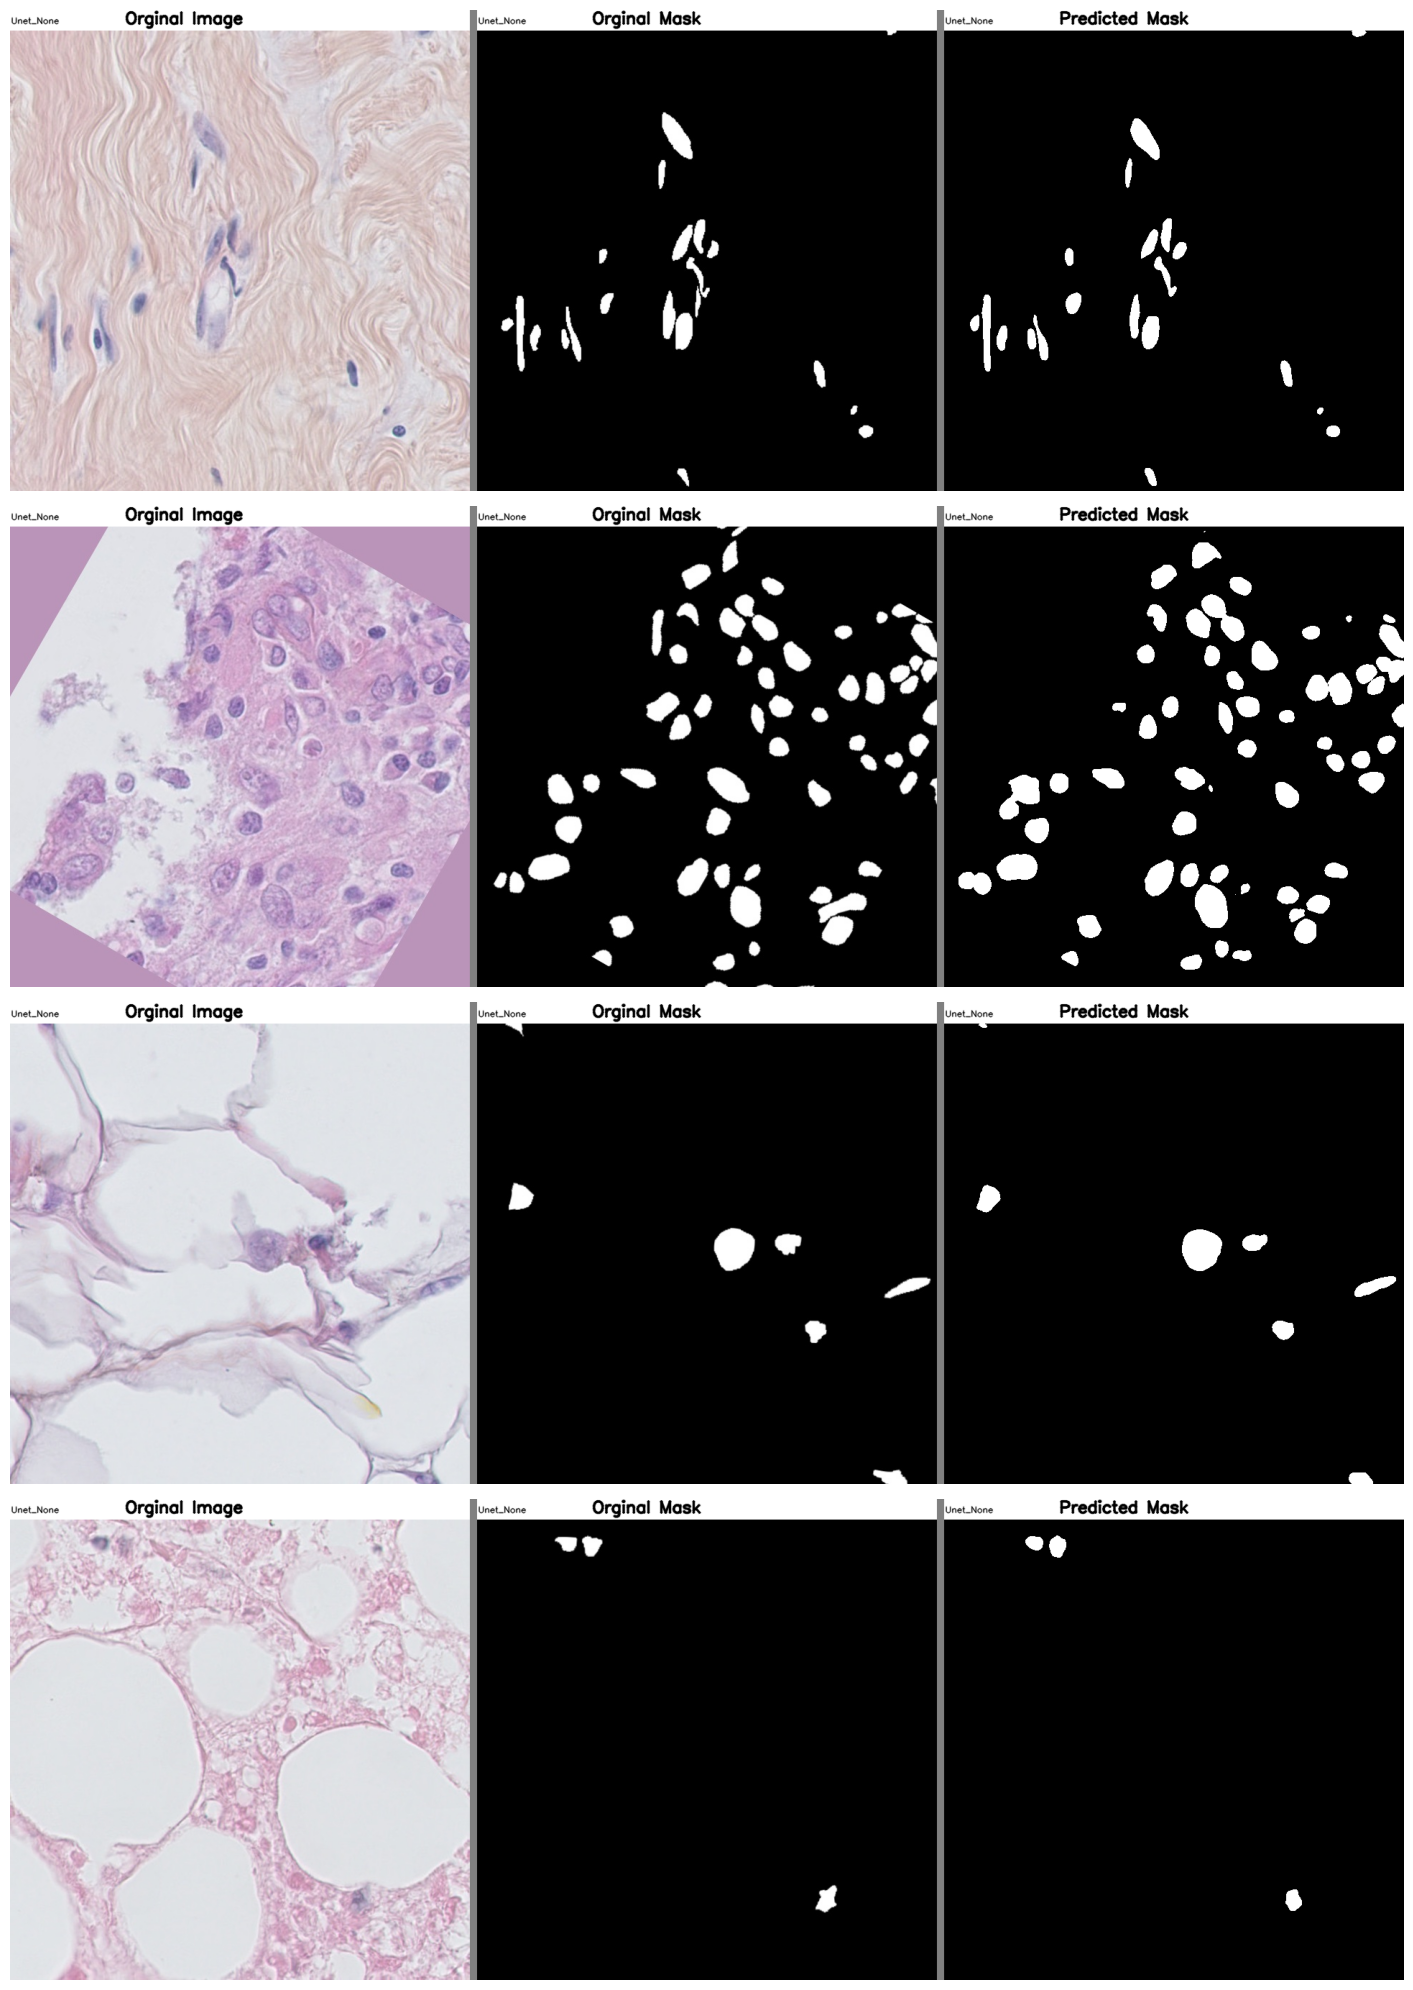

In [1]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
from glob import glob
import random

# Visualise the images and predicted masks on the test set
result_images = sorted(glob("/kaggle/input/notebooks/soumyajitghosh1729/notebook7b8e0c0889/results/*/*.png"))
if len(result_images) == 0:
    print("No images found in /kaggle/working/results/")
else:
    # Select 4 random images
    num_samples = min(4, len(result_images))
    sample_images = random.sample(result_images, num_samples)
    
    plt.figure(figsize=(20, 5 * num_samples))
    for i, img_path in enumerate(sample_images):
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        plt.subplot(num_samples, 1, i+1)
        plt.imshow(img)
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()
